<a href="https://colab.research.google.com/github/elvissoares/EQE595-SimMol/blob/main/notebooks/3_Ensemble_NVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula Prática 04 - Dinâmica Molecular em Ensemble NVE

Autor: [Prof. Elvis do A. Soares](https://github.com/elvissoares)

Contato: [elvis@peq.coppe.ufrj.br](mailto:elvis@peq.coppe.ufrj.br) - [Programa de Engenharia Química, PEQ/COPPE, UFRJ, Brasil](https://www.peq.coppe.ufrj.br/)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dinâmica Molecular no Ensemble NVE

- $N$: número de partículas
- $V$: volume
- $E$: energia


In [2]:
def ulj(r,epsilon=1.0,sigma=1.0):
    return 4*epsilon*((sigma/r)**12-(sigma/r)**6)

def duljdr(r,epsilon=1.0,sigma=1.0):
    return -4*epsilon*((12*(sigma/r)**12-6*(sigma/r)**6)/r)

In [3]:
class LJsystem():
    # Função que cria a classe
    def __init__(self,N_atoms, m = 1.0, epsilon = 1.0, sigma = 1.0, rcut = 2.5):
        self.N_atoms = N_atoms

        # parametros dos atomos
        self.m = m
        self.sigma = sigma
        self.epsilon = epsilon

        # parametro de cutoff da interação de LJ
        self.rcut = rcut

        # Arrays de posições
        self.r = np.zeros((self.N_atoms,3))

        # Arrays de velocidade
        self.v = np.zeros((self.N_atoms,3))

        # Arrays de aceleração
        self.a = np.zeros((self.N_atoms,3))

    def Set_Density(self,rho):
        self.rho = rho
        # calcular o tamanho da caixa necessária
        self.Vol = self.N_atoms/self.rho
        self.L = np.power(self.Vol,1/3.0)

    def Initialize_Positions(self):
        # Número de pontos em x e y
        Nx = Ny = Nz = int(np.ceil(np.power(self.N_atoms/4,1/3.0)))

        # Espaçamento entre os átomos
        dx = self.L/Nx
        dy = self.L/Ny
        dz = self.L/Nz

        # Posições possíveis em x e y numa rede cristalina tipo FCC
        id = 0
        for i in range(Nx):
            for j in range(Ny):
                for k in range(Nz):
                    if (id < self.N_atoms):
                        self.r[id][0] = i*dx
                        self.r[id][1] = j*dy
                        self.r[id][2] = k*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = i*dx
                        self.r[id][1] = (j+0.5)*dy
                        self.r[id][2] = (k+0.5)*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = (i+0.5)*dx
                        self.r[id][1] = j*dy
                        self.r[id][2] = (k+0.5)*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = (i+0.5)*dx
                        self.r[id][1] = (j+0.5)*dy
                        self.r[id][2] = k*dz
                        id +=1

    def Initialize_Velocities(self):
        # sorteia uma distribuição normal com devio padrão proporcional a temperatura
        self.v = np.random.randn(self.N_atoms,3)

        # retira qualquer movimento total
        self.v[:] -= self.v.mean(axis=0)

    def Get_KineticEnergy(self):
        self.K = 0.5*self.m*np.sum(self.v**2)
        return self.K

    def Build_NeighborList(self,rs=0.3):
        """Construindo uma lista de vizinhos de Verlet dentro de uma região rs"""
        self.rs = (rs+self.rcut)*self.epsilon
        self.NL = [[] for _ in range(self.N_atoms)]
        for i in range(self.N_atoms):
            for j in range(i+1, self.N_atoms):
                # calcula distancia entre duas particulas
                rij = self.r[i]-self.r[j]
                # aplicando pbc
                rij[:] -= np.rint(rij/self.L)*self.L
                # calcula distancia entre duas particulas
                rij_norm = np.linalg.norm(rij)
                # Vamos considerar somente interação dentro do raio de alcance
                if rij_norm < self.rs:
                    self.NL[i].append(j)

    def Calculate_Interactions(self):
        self.a[:] = 0.0
        self.U = 0.0
        self.W = 0.0
        for i in range(self.N_atoms):
            for j in self.NL[i]: # <-------- troca os limites
                # calcula distancia entre duas particulas
                rij = self.r[i]-self.r[j]
                # aplicando pbc
                rij[:] -= np.rint(rij/self.L)*self.L
                # calcula distancia entre duas particulas
                rij_norm = np.linalg.norm(rij)
                if rij_norm < self.rcut:
                    # calcula energia interna
                    self.U += ulj(rij_norm,self.epsilon,self.sigma)
                    # calcula a derivada do potencial
                    dudr = duljdr(rij_norm,self.epsilon,self.sigma)
                    # calcula aceleração na particula i
                    self.a[i] += -dudr*rij/rij_norm
                    # calcula aceleração na particula j usando 3ª Lei de Newton
                    self.a[j] += dudr*rij/rij_norm

    def Get_PotentialEnergy(self):
        return self.U

    def Get_Energies(self):
        self.Get_KineticEnergy()
        return self.K, self.U


    def Set_TimeStep(self,h):
        self.h = h

    def Calculate_TimeStep(self):
        # update das velocidades
        self.v[:] += 0.5*self.a*self.h
        # update das posições
        self.r[:] += self.h * self.v
        # condição de contorno periódica
        self.r[:] = self.r % self.L
        # calcula nova aceleração
        self.Calculate_Interactions()
        # update das velocidades
        self.v[:] += 0.5*self.a*self.h

    def RunSimulation(self,N_steps,Step_to_print=50,Step_tolist_update=20):
        self.N_steps = N_steps
        self.Step_to_print = Step_to_print # steps to print output
        self.Step_tolist_update = Step_tolist_update

        self.Build_NeighborList()
        self.Calculate_Interactions()

        print('iter\t K\t U\t E')

        t = []
        K = []
        U = []
        E = []

        Ktemp, Utemp = self.Get_Energies()
        Kmed = Ktemp
        Umed = Utemp
        Emed = Ktemp+Utemp

        for i in range(1,self.N_steps+1):

            if i % self.Step_tolist_update == 0:
                self.Build_NeighborList()

            self.Calculate_TimeStep()

            Ktemp, Utemp = self.Get_Energies()
            Kmed += Ktemp
            Umed += Utemp
            Emed += Ktemp+Utemp

            if i % self.Step_to_print == 0:
                Kmed /= self.Step_to_print
                Umed /= self.Step_to_print
                Emed /= self.Step_to_print
                t.append(i)
                K.append(Kmed)
                U.append(Umed)
                E.append(Emed)
                print(f'{i:5d}\t {Kmed:.4f}\t {Umed:.4f}\t {Emed:.4f}')
                Kmed = 0.0
                Umed = 0.0
                Emed = 0.0

        return np.array(t), np.array(K), np.array(U), np.array(E)

Criando condição inicial

In [4]:
rho = 0.55
kT = 1.38

N_atoms=256

lj = LJsystem(N_atoms=N_atoms,m=1.0,epsilon=1.0,sigma=1.0)
lj.Set_Density(rho=rho)
lj.Initialize_Positions()
lj.Initialize_Velocities()
lj.Set_TimeStep(h=0.003)

Realizando a simulação

In [6]:
t, K, U, E = lj.RunSimulation(N_steps=2000,Step_to_print=50)

iter	 K	 U	 E
   50	 378.7297	 -931.0827	 -552.3529
  100	 340.9678	 -874.7486	 -533.7808
  150	 373.9070	 -906.7693	 -532.8623
  200	 369.0006	 -902.3629	 -533.3624
  250	 374.5907	 -908.0814	 -533.4907
  300	 364.7007	 -898.0638	 -533.3632
  350	 368.6902	 -902.0955	 -533.4054
  400	 369.0727	 -902.5169	 -533.4443
  450	 371.8128	 -905.2363	 -533.4235
  500	 370.8681	 -904.3328	 -533.4647
  550	 367.9777	 -901.1944	 -533.2167
  600	 371.4441	 -905.1366	 -533.6925
  650	 377.8649	 -912.1134	 -534.2485
  700	 385.0034	 -919.2225	 -534.2191
  750	 380.5328	 -914.4257	 -533.8929
  800	 380.4547	 -914.6911	 -534.2364
  850	 382.5047	 -916.4120	 -533.9073
  900	 373.6420	 -907.6648	 -534.0227
  950	 384.7740	 -918.7569	 -533.9829
 1000	 386.1234	 -920.1521	 -534.0287
 1050	 385.3742	 -919.4267	 -534.0525
 1100	 386.6962	 -921.0829	 -534.3867
 1150	 380.3471	 -914.2512	 -533.9041
 1200	 369.6038	 -902.9655	 -533.3618
 1250	 375.0553	 -908.0421	 -532.9868
 1300	 382.7912	 -916.1843	 -533.393

Gráfico da evolução de $U$, $K$ e $E$ como função dos passos de iteração

Text(0.5, 0, '$t/\\tau$')

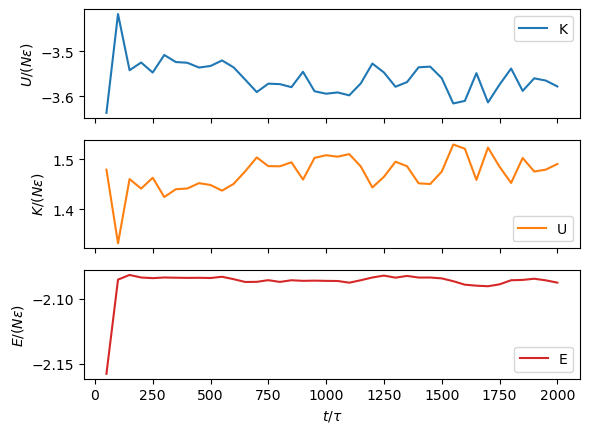

In [7]:
fig, axs = plt.subplots(3, 1, sharex=True)

axs[0].plot(t,U/lj.N_atoms,color='C0',label='K')
axs[0].legend(loc='best')
axs[0].set_ylabel(r'$U/(N\epsilon)$')

axs[1].plot(t,K/lj.N_atoms,color='C1',label='U')
axs[1].legend(loc='best')
axs[1].set_ylabel(r'$K/(N\epsilon)$')

axs[2].plot(t,E/lj.N_atoms,color='C3',label='E')
axs[2].legend(loc='best')
axs[2].set_ylabel(r'$E/(N\epsilon)$')

axs[2].set_xlabel(r'$t/\tau$')

## Distribuição de Maxwell-Boltzmann

A distribuição de velocidades das moléculas no equilíbrio termodinâmico é dada por 
$$f(v_x) = \frac{1}{\sqrt{2\pi \sigma_{v_x}^2}}e^{-\frac{v_x^2}{2 \sigma_{v_x}^2 }}$$
com $\sigma_{v_x}$ sendo o desvio padrão da velocidade. 

(0.0, 0.5)

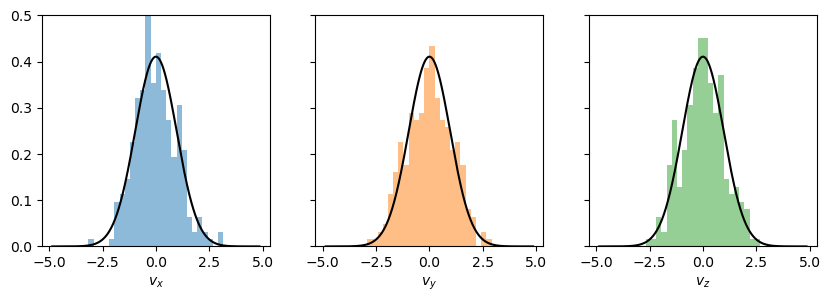

In [8]:
fig, axs = plt.subplots(1, 3, sharey=True,figsize=(10,3))

# calucla média e desvio padrão da distribuição de velocidades em x
vxmean = lj.v[:,0].mean()
sigmavx = lj.v[:,0].std()

# cria uma distribuição gaussiana de velocidades em x
vxarray = np.arange(-5.0,5.0,0.01)*sigmavx+ vxmean
fvx = np.sqrt(1/(2*np.pi*sigmavx**2))*np.exp(-0.5*(vxarray-vxmean)**2/sigmavx**2)

axs[0].hist(lj.v[:,0],bins=40,range=(vxarray.min(),vxarray.max()),density=True,color='C0',alpha=0.5)
axs[0].plot(vxarray,fvx,'k')
axs[0].set_xlabel(r'$v_x$')

axs[1].hist(lj.v[:,1],bins=40,range=(vxarray.min(),vxarray.max()),density=True,color='C1',alpha=0.5)
axs[1].plot(vxarray,fvx,'k')
axs[1].set_xlabel(r'$v_y$')

axs[2].hist(lj.v[:,2],bins=40,range=(vxarray.min(),vxarray.max()),density=True,color='C2',alpha=0.5)
axs[2].plot(vxarray,fvx,'k')
axs[2].set_xlabel(r'$v_z$')

axs[0].set_ylim(0,0.5)

## Cálculo da Temperatura

Da termodinâmica sabemos que para um gás de moléculas monoatômicas simples temos

$$\frac{3}{2} N k_B T = \sum_{i=1}^N \frac{m_i v_i^2}{2} = K$$

ou seja, a energia cinética total das partículas é igual a energia térmica das partículas. Desta forma, podemos definir a temperatura como sendo

$$ k_B T = \frac{2}{3} \frac{K}{N}$$

a energia cinética média das partículas.

Conectando com a distribuição de Maxwell-Boltzmann, vemos que 
$$\sigma_{v_x}^2 = \frac{k_B T}{m}$$

> **<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**
> 
> Crie uma função que calcula a temperatura a partir das velocidades

In [ ]:
def calculate_temperature(ljclass):
    ...

## Cálculo da Pressão

Vimos que a energia potencial do sistema é dada por

$$U = \frac{1}{2}\sum_{i=1}^N \sum_{j \neq i}^N u(\boldsymbol{r}_{ij})$$

Da termodinâmica, sabemos que

$$P = \rho k_B T - \left(\frac{\partial U}{\partial V}\right)_{N,S}$$

Como a distância entre duas partículas $\boldsymbol{r}_{ij}$ pode ser escrita em termos de um comprimento característico da caixa de simulação $\ell$ tal que $\boldsymbol{r}_{ij} = \boldsymbol{s}_{ij} \ell$ e que $V = \ell^3$, podemos escrever que

$$\left(\frac{\partial U}{\partial V}\right)_{N,S} = \frac{1}{2}\sum_{i=1}^N \sum_{j \neq i}^N \frac{\partial u(\boldsymbol{r}_{ij})}{\partial \boldsymbol{r}_{ij}} \cdot \frac{\partial \boldsymbol{r}_{ij}}{\partial V}$$

e usando que $\frac{\partial \boldsymbol{r}_{ij}}{\partial V} = \boldsymbol{r}_{ij}/(3V)$ chegamos a

$$P = \rho k_B T + \frac{W}{3V}$$

$$W=  \frac{1}{2}\sum_{i=1}^N \sum_{j \neq i}^N \boldsymbol{f}_{ij} \cdot \boldsymbol{r}_{ij}$$

sendo $W$ o termo de virial que pode ser calculado pelo produto entre as forças e os deslocamentos.

> **<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**
> 
> Crie uma função que calcula a pressão a partir das posições

In [ ]:
def calculate_pressure(ljclass):
    ...

## Adicionando funções na Classe `LJsystem`

In [ ]:
class LJsystem():
    # Função que cria a classe
    def __init__(self,N_atoms, m = 1.0, epsilon = 1.0, sigma = 1.0, rcut = 2.5):
        self.N_atoms = N_atoms

        # parametros dos atomos
        self.m = m
        self.sigma = sigma
        self.epsilon = epsilon

        # parametro de cutoff da interação de LJ
        self.rcut = rcut

        # Arrays de posições
        self.r = np.zeros((self.N_atoms,3))

        # Arrays de velocidade
        self.v = np.zeros((self.N_atoms,3))

        # Arrays de aceleração
        self.a = np.zeros((self.N_atoms,3))

    def Set_Density(self,rho):
        self.rho = rho
        # calcular o tamanho da caixa necessária
        self.Vol = self.N_atoms/self.rho
        self.L = np.power(self.Vol,1/3.0)

    def Initialize_Positions(self):
        # Número de pontos em x e y
        Nx = Ny = Nz = int(np.ceil(np.power(self.N_atoms/4,1/3.0)))

        # Espaçamento entre os átomos
        dx = self.L/Nx
        dy = self.L/Ny
        dz = self.L/Nz

        # Posições possíveis em x e y numa rede cristalina tipo FCC
        id = 0
        for i in range(Nx):
            for j in range(Ny):
                for k in range(Nz):
                    if (id < self.N_atoms):
                        self.r[id][0] = i*dx
                        self.r[id][1] = j*dy
                        self.r[id][2] = k*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = i*dx
                        self.r[id][1] = (j+0.5)*dy
                        self.r[id][2] = (k+0.5)*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = (i+0.5)*dx
                        self.r[id][1] = j*dy
                        self.r[id][2] = (k+0.5)*dz
                        id +=1

                    if (id < self.N_atoms):
                        self.r[id][0] = (i+0.5)*dx
                        self.r[id][1] = (j+0.5)*dy
                        self.r[id][2] = k*dz
                        id +=1

    def Initialize_Velocities(self,kT= 1.0):
        self.kT = kT

        # sorteia uma distribuição normal com devio padrão proporcional a temperatura
        self.v = np.sqrt(self.kT/self.m)*np.random.randn(self.N_atoms,3)

        # retira qualquer movimento total
        self.v[:] -= self.v.mean(axis=0)

    def Get_KineticEnergy(self):
        self.K = 0.5*self.m*np.sum(self.v**2)
        return self.K

    def Build_NeighborList(self,rs=2.8):
        """Construindo uma lista de vizinhos de Verlet dentro de uma região rcell"""
        self.rs = rs
        self.NL = [[] for _ in range(self.N_atoms)]
        for i in range(self.N_atoms):
            for j in range(i+1, self.N_atoms):
                # calcula distancia entre duas particulas
                rij = self.r[i]-self.r[j]
                # aplicando pbc
                rij[:] -= np.rint(rij/self.L)*self.L
                # calcula distancia entre duas particulas
                rij_norm = np.linalg.norm(rij)
                # Vamos considerar somente interação dentro do raio de corte
                if rij_norm < self.rs:
                    self.NL[i].append(j)

    def Calculate_Interactions(self):
        self.a[:] = 0.0
        self.U = 0.0
        self.W = 0.0
        for i in range(self.N_atoms):
            for j in self.NL[i]: # <-------- troca os limites
                # calcula distancia entre duas particulas
                rij = self.r[i]-self.r[j]
                # aplicando pbc
                rij[:] -= np.rint(rij/self.L)*self.L
                # calcula distancia entre duas particulas
                rij_norm = np.linalg.norm(rij)
                if rij_norm < self.rcut:
                    # calcula energia interna
                    self.U += ulj(rij_norm,self.epsilon,self.sigma)
                    # calcula a derivada do potencial
                    dudr = duljdr(rij_norm,self.epsilon,self.sigma)
                    # calcula aceleração na particula i
                    self.a[i] += -dudr*rij/rij_norm
                    # calcula aceleração na particula j usando 3ª Lei de Newton
                    self.a[j] += dudr*rij/rij_norm
                    # calcula correção da pressao
                    self.W += dudr*rij_norm

    def Get_PotentialEnergy(self):
        return self.U

    def Get_Energies(self):
        self.Get_KineticEnergy()
        kT = 2*self.K/(3*self.N_atoms)
        return self.K, self.U, kT

    def Calculate_Pressure(self):
        kT = 2*self.K/(3*self.N_atoms)
        return self.rho*kT + self.W/(3*self.Vol)

    def Set_TimeStep(self,h):
        self.h = h

    def Calculate_TimeStep(self):
        # update das velocidades
        self.v[:] += 0.5*self.a*self.h
        # update das posições
        self.r[:] += self.h * self.v
        # condição de contorno periódica
        self.r[:] = self.r % self.L
        # calcula nova aceleração
        self.Calculate_Interactions()
        # update das velocidades
        self.v[:] += 0.5*self.a*self.h

    def RunSimulation(self,N_steps,Step_to_print=50,Step_tolist_update=20):
        self.N_steps = N_steps
        self.Step_to_print = Step_to_print # steps to print output
        self.Step_tolist_update = Step_tolist_update

        self.Build_NeighborList()
        self.Calculate_Interactions()

        print('iter\t K\t U\t E\t T\t P')

        t = []
        K = []
        U = []
        E = []
        T = []
        P = []

        Ktemp, Utemp, Ttemp = self.Get_Energies()
        Ptemp = self.Calculate_Pressure()
        Kmed = Ktemp
        Umed = Utemp
        Emed = Ktemp+Utemp
        Tmed = Ttemp
        Pmed = Ptemp

        for i in range(1,self.N_steps+1):

            if i % self.Step_tolist_update == 0:
                self.Build_NeighborList()

            self.Calculate_TimeStep()

            Ktemp, Utemp, Ttemp = self.Get_Energies()
            Ptemp = self.Calculate_Pressure()
            Kmed += Ktemp
            Umed += Utemp
            Tmed += Ttemp
            Emed += Ktemp+Utemp
            Pmed += Ptemp

            if i % self.Step_to_print == 0:
                Kmed /= Step_to_print
                Umed /= Step_to_print
                Emed /= Step_to_print
                Tmed /= Step_to_print
                Pmed /= Step_to_print
                t.append(i)
                K.append(Kmed)
                U.append(Umed)
                E.append(Emed)
                T.append(Tmed)
                P.append(Pmed)
                print(f'{i:5d}\t {Kmed:.4f}\t {Umed:.4f}\t {Emed:.4f}\t {Tmed:.4f}\t {Pmed:.4f}')
                Kmed = 0.0
                Umed = 0.0
                Emed = 0.0
                Tmed = 0.0
                Pmed = 0.0

        return np.array(t), np.array(K), np.array(U), np.array(E), np.array(T), np.array(P)

In [ ]:
rho = 0.55
kT = 1.38

N_atoms=256

lj = LJsystem(N_atoms=N_atoms,m=1.0,epsilon=1.0,sigma=1.0)
lj.Set_Density(rho=rho)
lj.Initialize_Positions()
lj.Initialize_Velocities(kT=kT)
lj.Set_TimeStep(h=0.003)

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(lj.r[:,0],lj.r[:,1],'o',ms=10.0,alpha=0.5) # posição das partículas
plt.quiver(lj.r[:,0],lj.r[:,1],lj.v[:,0],lj.v[:,1],color='C0') # vetor de velocidade

plt.xlim(0,lj.L)
plt.ylim(0,lj.L)

plt.xlabel('x')
plt.ylabel('y')

In [ ]:
t, K, U, E, T, P = lj.RunSimulation(N_steps=2000,Step_to_print=50)

Gráfico das posições finais das partículas

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(lj.r[:,0],lj.r[:,1],'o',ms=10.0,alpha=0.5) # posição das partículas
plt.quiver(lj.r[:,0],lj.r[:,1],lj.v[:,0],lj.v[:,1],color='C0') # vetor de velocidade

plt.xlim(0,lj.L)
plt.ylim(0,lj.L)

plt.xlabel('x')
plt.ylabel('y')

Gráfico da evolução de $U$ e $T$ como função dos passos de iteração

In [ ]:
fig, axs = plt.subplots(4, 1, sharex=True)

axs[0].plot(t,E/lj.N_atoms,'k',label='E')
axs[0].legend(loc='best')
axs[0].set_ylabel(r'$E/(N\epsilon)$')

axs[1].plot(t,U/lj.N_atoms,label='U')
axs[1].legend(loc='best')
axs[1].set_ylabel(r'$U/(N\epsilon)$')

axs[2].plot(t,T,color='C3',label='T')
axs[2].legend(loc='best')
axs[2].set_ylabel(r'$k_B T/\epsilon$')

axs[3].plot(t,P,color='C2',label='P')
axs[3].legend(loc='best')
axs[3].set_xlabel(r'$t/\tau$')
axs[3].set_ylabel(r'$P \sigma^3/\epsilon$')

## Calculando Médias e Desvios Padrão

In [ ]:
teq = 150
subsett = t[t>teq]
subsetT = T[t>teq]
subsetP = P[t>teq]
subsetU = U[t>teq]/lj.N_atoms

Energia Interna

In [ ]:
Umean = subsetU.mean()

sigmaU = subsetU.std()

print(rf"A energia interna do sistema é {Umean:.2f}+-{sigmaU:.2f} por partícula")

In [ ]:
plt.xlabel(r'$U/\epsilon$')
plt.ylabel('Densidade de Probabilidade')

uarray = np.arange(-3.6,-3.2,0.001)
plt.plot(uarray,np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),color='k')

n, bins = np.histogram(subsetU,bins=15,range=(uarray.min(),uarray.max()),density=True)
meanbins = 0.5*(bins[1:]+bins[:-1])
plt.scatter(meanbins,n,marker='o',color='C0')

Temperatura

In [ ]:
Tmean = subsetT.mean()
sigmaT = subsetT.std()

print(rf"A temperatura do sistema é {Tmean:.2f}+-{sigmaT:.2f}")

In [ ]:
plt.xlabel(r'$k_B T/\epsilon$')
plt.ylabel('Densidade de Probabilidade')

Tarray = np.arange(1.2,1.5,0.001)
plt.plot(Tarray,np.sqrt(1/(2*np.pi*sigmaT**2))*np.exp(-0.5*(Tarray-Tmean)**2/sigmaT**2),color='k')

n, bins = np.histogram(subsetT,bins=15,range=(Tarray.min(),Tarray.max()),density=True)
meanbins = 0.5*(bins[1:]+bins[:-1])
plt.scatter(meanbins,n,marker='o',color='C3')

Pressão

In [ ]:
Pmean = subsetP.mean()
sigmaP = subsetP.std()

print(rf"A pressão do sistema é {Pmean:.2f}+-{sigmaP:.2f}")

In [ ]:
plt.xlabel(r'$P \sigma^3/\epsilon$')
plt.ylabel('Densidade de Probabilidade')

Parray = np.arange(0.0,1.6,0.001)
plt.plot(Parray,np.sqrt(1/(2*np.pi*sigmaP**2))*np.exp(-0.5*(Parray-Pmean)**2/sigmaP**2),color='k')

n, bins = np.histogram(subsetP,bins=15,range=(Parray.min(),Parray.max()),density=True)
meanbins = 0.5*(bins[1:]+bins[:-1])
plt.scatter(meanbins,n,marker='o',color='C2')

> **<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**
> 
> Refaça a simulação usando 864 partículas. Compare os resultados.